# 作業 2 — 勞動法規問答 LINE Bot

請找一份PDF或爬取一個網站中的資料後，實作一個問答系統(介面自行發揮)，並確保連續問5個問題後至少可以答對3題。請繳交程式碼和測試截圖。

## 加分項:
擴大資料來源到兩份以上的資料，問答仍然能夠有一樣的正確率

---

## 實作說明
- **資料來源 1**：勞動基準法權益簡介（工資、工時、加班費、假期、資遣、退休）
- **資料來源 2**：性別平等工作法（性別歧視禁止、產假、陪產假、育嬰留停、性騷擾防治）
- **介面**：LINE Bot（透過 Flask + ngrok）
- **RAG 架構**：HuggingFace Embedding → InMemoryVectorStore → Groq LLM

# Step 1: 安裝套件 & 載入環境變數

需要在 `.env` 中設定以下變數：
```
GROQ_API_KEY=your_groq_api_key
NGROK_TOKEN=your_ngrok_token
LINE_ACCESS_TOKEN=your_line_access_token
LINE_SECRET=your_line_secret
```

In [17]:
import json
import os
import re

import requests
from bs4 import BeautifulSoup, Tag
from dotenv import load_dotenv
from flask import Flask, request as flask_request
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from linebot.v3 import WebhookHandler
from linebot.v3.exceptions import InvalidSignatureError
from linebot.v3.messaging import (
    ApiClient,
    Configuration,
    MessagingApi,
    ReplyMessageRequest,
    TextMessage,
)
from linebot.v3.webhooks import MessageEvent, TextMessageContent
from pyngrok import ngrok

load_dotenv(override=True)

True

# Step 2: 建立 Embedding Model & Vector Store

In [2]:
embedding = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")
vector_store = InMemoryVectorStore(embedding)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Step 3: 爬取網站資料 & Chunking

兩份資料來源（皆從勞動部官網即時爬取）：
1. **勞動基準法** — 爬取 [勞動部勞動法令查詢系統](https://laws.mol.gov.tw/FLAW/FLAWDAT0202.aspx?id=FL014930) 所有條文
2. **性別平等工作法** — 爬取 [勞動部勞動法令查詢系統](https://laws.mol.gov.tw/FLAW/FLAWDAT0202.aspx?id=FL015149) 所有條文

使用 `RecursiveCharacterTextSplitter` 進行 chunking，模擬真實 RAG pipeline。

In [3]:
# ---------------------------------------------------------------------------
# 3-1: 定義爬蟲函式 — 爬取勞動部法令查詢系統的條文
# ---------------------------------------------------------------------------

def scrape_law_articles(url: str, law_name: str) -> list[Document]:
    """
    爬取勞動部勞動法令查詢系統的「所有條文」頁面。
    頁面結構：每條以 <a href="FLAWDOC01...flno=N">第 N 條</a> 標示，
    條文內容在該連結的 parent 之後的 sibling 節點中。
    """
    resp = requests.get(url, timeout=60)
    soup = BeautifulSoup(resp.content, "html.parser", from_encoding="utf-8")

    # 用 href 模式找所有條號連結
    article_links = soup.find_all("a", href=re.compile(r"FLAWDOC01.*flno="))

    if not article_links:
        print(f"  警告：在 {url} 中未找到任何條文連結")
        return []

    docs = []
    for link in article_links:
        article_no = link.get_text(strip=True)  # e.g. "第 1 條"

        # 收集條號之後、下一個條號之前的所有文字
        content_parts = []
        node = link.parent.next_sibling
        while node:
            # 只有 Tag 才能用 BeautifulSoup 的 find()
            # NavigableString (純文字) 的 str.find() 不接受 keyword args
            if isinstance(node, Tag):
                next_link = node.find("a", href=re.compile(r"FLAWDOC01.*flno="))
                if next_link:
                    break
            text = node.get_text(strip=True) if isinstance(node, Tag) else str(node).strip()
            if text:
                content_parts.append(text)
            node = node.next_sibling

        content = "\n".join(content_parts).strip()
        if content:
            docs.append(Document(
                page_content=f"{article_no}\n{content}",
                metadata={"來源": law_name, "條號": article_no}
            ))

    return docs


# ---------------------------------------------------------------------------
# 3-2: 爬取兩份法規
# ---------------------------------------------------------------------------

LABOR_URL = "https://laws.mol.gov.tw/FLAW/FLAWDAT0202.aspx?id=FL014930"
GENDER_URL = "https://laws.mol.gov.tw/FLAW/FLAWDAT0202.aspx?id=FL015149"

print("正在爬取勞動基準法...")
labor_raw_docs = scrape_law_articles(LABOR_URL, "勞動基準法")
print(f"  取得 {len(labor_raw_docs)} 條")

print("正在爬取性別平等工作法...")
gender_raw_docs = scrape_law_articles(GENDER_URL, "性別平等工作法")
print(f"  取得 {len(gender_raw_docs)} 條")

all_raw_docs = labor_raw_docs + gender_raw_docs
print(f"\n共取得 {len(all_raw_docs)} 條原始條文")

正在爬取勞動基準法...
  取得 98 條
正在爬取性別平等工作法...
  取得 50 條

共取得 148 條原始條文


In [4]:
# 預覽爬取結果
print("=== 勞動基準法 前 3 條 ===")
for doc in labor_raw_docs[:3]:
    print(f"\n[{doc.metadata['條號']}]")
    print(doc.page_content[:150], "..." if len(doc.page_content) > 150 else "")

print("\n=== 性別平等工作法 前 3 條 ===")
for doc in gender_raw_docs[:3]:
    print(f"\n[{doc.metadata['條號']}]")
    print(doc.page_content[:150], "..." if len(doc.page_content) > 150 else "")

=== 勞動基準法 前 3 條 ===

[第 1 條]
第 1 條
為規定勞動條件最低標準，保障勞工權益，加強勞雇關係，促進社會與經
濟發展，特制定本法；本法未規定者，適用其他法律之規定。
雇主與勞工所訂勞動條件，不得低於本法所定之最低標準。 

[第 2 條]
第 2 條
本法用詞，定義如下：
一、勞工：指受雇主僱用從事工作獲致工資者。
二、雇主：指僱用勞工之事業主、事業經營之負責人或代表事業主處理有
    關勞工事務之人。
三、工資：指勞工因工作而獲得之報酬；包括工資、薪金及按計時、計日
    、計月、計件以現金或實物等方式給付之獎金、津貼 ...

[第 3 條]
第 3 條
本法於左列各業適用之：
一、農、林、漁、牧業。
二、礦業及土石採取業。
三、製造業。
四、營造業。
五、水電、煤氣業。
六、運輸、倉儲及通信業。
七、大眾傳播業。
八、其他經中央主管機關指定之事業。
依前項第八款指定時，得就事業之部分工作場所或工作者指定適用。
本法適 ...

=== 性別平等工作法 前 3 條 ===

[第 1 條]
第 1 條
為保障工作權之性別平等，貫徹憲法消除性別歧視、促進性別地位實質平
等之精神，爰制定本法。
工作場所性騷擾事件，除校園性騷擾事件依性別平等教育法規定處理外，
依本法規定處理。 

[第 2 條]
第 2 條
雇主與受僱者之約定優於本法者，從其約定。
本法於公務人員、教育人員及軍職人員，亦適用之。但第三十二條之一、
第三十二條之二、第三十三條、第三十四條、第三十八條及第三十八條之
一之規定，不適用之。
公務人員、教育人員及軍職人員之申訴、救濟及處理程序，依各該人事法
令之規定。
本 ...

[第 3 條]
第 3 條
本法用詞，定義如下：
一、受僱者：指受雇主僱用從事工作獲致薪資者。
二、求職者：指向雇主應徵工作之人。
三、雇主：指僱用受僱者之人、公私立機構或機關。代表雇主行使管理權
    之人或代表雇主處理有關受僱者事務之人，視同雇主。要派單位使用
    派遣勞工時，視為第八條、第九條 ...


In [5]:
# ---------------------------------------------------------------------------
# 3-3: Text Chunking — 使用 RecursiveCharacterTextSplitter
# ---------------------------------------------------------------------------
# 法條本身多半不長，但部分條文（如加班費、特休）段落較大，
# 透過 chunk 切割可以提升 embedding 的精準度。

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,       # 每個 chunk 最多 300 字元
    chunk_overlap=50,     # 前後重疊 50 字元，避免語意斷裂
    separators=["\n\n", "\n", "。", "，", " "],
)

chunked_docs = text_splitter.split_documents(all_raw_docs)
print(f"Chunking 完成：{len(all_raw_docs)} 條原始條文 → {len(chunked_docs)} 個 chunks")
print(f"平均每個 chunk {sum(len(d.page_content) for d in chunked_docs) // len(chunked_docs)} 字元")

Chunking 完成：148 條原始條文 → 176 個 chunks
平均每個 chunk 150 字元


In [6]:
# ---------------------------------------------------------------------------
# 3-4: 將 chunks 載入 Vector Store
# ---------------------------------------------------------------------------

vector_store.add_documents(documents=chunked_docs)
print(f"已將 {len(chunked_docs)} 個 chunks 加入向量資料庫")

已將 176 個 chunks 加入向量資料庫


# Step 4: 建立 LLM & RAG Agent

In [7]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [8]:
def rag_answer(question: str) -> str:
    """根據問題從向量資料庫檢索相關文件，並用 LLM 生成回答"""
    # 檢索相關文件
    retrieved_docs = vector_store.similarity_search(question, k=4)
    docs_content = "\n\n".join(
        f"【{doc.metadata.get('來源', '')} - {doc.metadata.get('主題', '')}】\n{doc.page_content}"
        for doc in retrieved_docs
    )

    # 組合 prompt
    system_message = (
        "你是一個專業的台灣勞動法規問答助理。"
        "請根據以下檢索到的法規內容來回答問題。"
        "如果檢索內容中沒有相關資訊，請誠實說不知道。"
        "請用繁體中文、簡潔明確地回答，最多三句話。"
        f"\n\n參考資料：\n{docs_content}"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": question},
    ]

    response = llm.invoke(messages)
    return response.content


# 測試一下
test_answer = rag_answer("一例一休是什麼？")
print(test_answer)

根據勞動基準法第36條，勞工每七日中應有二日之休息，其中一日為例假，一日為休息日，這被稱為「一例一休」。


# Step 5: 常見測試問答 10 題
涵蓋兩份資料來源，用來驗證 RAG 問答系統的正確率。

In [9]:
test_qa = [
    # --- 勞動基準法 (5 題) ---
    {
        "question": "勞工每日正常工時上限是幾小時？每週呢？",
        "expected": "每日不得超過八小時，每週不得超過四十小時（第 30 條）",
    },
    {
        "question": "加班前2小時的加班費怎麼計算？",
        "expected": "按平日每小時工資額加給三分之一以上（第 24 條）",
    },
    {
        "question": "工作滿1年但未滿2年的勞工有幾天特休？",
        "expected": "七日（第 38 條）",
    },
    {
        "question": "雇主資遣勞工時，工作三年以上者應提前幾天預告？",
        "expected": "三十日前預告（第 16 條）",
    },
    {
        "question": "勞工自請退休的條件是什麼？",
        "expected": "工作十五年以上年滿五十五歲、工作二十五年以上、或工作十年以上年滿六十歲（第 53 條）",
    },
    # --- 性別平等工作法 (5 題) ---
    {
        "question": "女性員工分娩前後可以請幾星期的產假？",
        "expected": "產假八星期（第 15 條）",
    },
    {
        "question": "陪產假有幾天？",
        "expected": "陪產檢及陪產假七日（第 15 條）",
    },
    {
        "question": "生理假每月可以請幾天？薪資怎麼算？",
        "expected": "每月一日，全年未逾三日不併入病假，薪資減半發給（第 14 條）",
    },
    {
        "question": "僱用多少人以上的企業需要訂定性騷擾防治措施？",
        "expected": "僱用受僱者三十人以上（第 13 條）",
    },
    {
        "question": "雇主可以因為員工懷孕而要求離職嗎？",
        "expected": "不可以，規定或約定無效，勞動契約之終止不生效力（第 11 條）",
    },
]

# 執行測試
print("=" * 60)
print("勞動法規問答系統 — 測試 10 題")
print("=" * 60)

for i, qa in enumerate(test_qa, 1):
    answer = rag_answer(qa["question"])
    print(f"\n【Q{i}】{qa['question']}")
    print(f"  期望答案：{qa['expected']}")
    print(f"  系統回答：{answer}")

勞動法規問答系統 — 測試 10 題

【Q1】勞工每日正常工時上限是幾小時？每週呢？
  期望答案：每日不得超過八小時，每週不得超過四十小時（第 30 條）
  系統回答：根據勞動基準法第30條，勞工正常工作時間，每日不得超過八小時，每週不得超過四十小時。

【Q2】加班前2小時的加班費怎麼計算？
  期望答案：按平日每小時工資額加給三分之一以上（第 24 條）
  系統回答：根據勞動基準法第24條規定，加班前2小時的加班費應按平日每小時工資額加給三分之一以上。

【Q3】工作滿1年但未滿2年的勞工有幾天特休？
  期望答案：七日（第 38 條）
  系統回答：工作滿1年但未滿2年的勞工，應享有7天的特別休假。

【Q4】雇主資遣勞工時，工作三年以上者應提前幾天預告？
  期望答案：三十日前預告（第 16 條）
  系統回答：根據勞動基準法第16條，雇主資遣勞工時，工作三年以上者應提前30天預告。

【Q5】勞工自請退休的條件是什麼？
  期望答案：工作十五年以上年滿五十五歲、工作二十五年以上、或工作十年以上年滿六十歲（第 53 條）
  系統回答：根據勞動基準法第53條，勞工有下列情形之一，得自請退休：工作十五年以上年滿五十五歲、工作二十五年以上或工作十年以上年滿六十歲。

【Q6】女性員工分娩前後可以請幾星期的產假？
  期望答案：產假八星期（第 15 條）
  系統回答：女性員工分娩前後可以請八星期的產假。

【Q7】陪產假有幾天？
  期望答案：陪產檢及陪產假七日（第 15 條）
  系統回答：根據《性別平等工作法》，陪產假為7日，期間薪資照給。

【Q8】生理假每月可以請幾天？薪資怎麼算？
  期望答案：每月一日，全年未逾三日不併入病假，薪資減半發給（第 14 條）
  系統回答：女性受僱者因生理日致工作有困難者，每月得請生理假一日，全年請假日數未逾三日，不併入病假計算。生理假薪資，減半發給。

【Q9】僱用多少人以上的企業需要訂定性騷擾防治措施？
  期望答案：僱用受僱者三十人以上（第 13 條）
  系統回答：僱用三十人以上的企業需要訂定性騷擾防治措施、申訴及懲戒規範，並在工作場所公開揭示。僱用十人以上未達三十人的企業則需要訂定申訴管道，並在工作場所公開揭示。

【Q10】雇主可以因為員工懷孕而要求離職嗎？
  期望答案：不可以，規定或約定無效，勞動

增加到兩個不同法規也能正常回答問題，確保系統的拓展性和準確率。

# Step 6: 設定 ngrok 隧道

In [ ]:
# 從 .env 讀取 ngrok token
ngrok.set_auth_token(os.getenv("NGROK_TOKEN"))
ngrok_tunnel = ngrok.connect(addr="5000", proto="http", bind_tls=True)
print(f"Tunnel URL: {ngrok_tunnel.public_url}")
print("請將此 URL 貼到 LINE Developers Console 的 Webhook URL")

# Step 7: 啟動 LINE Bot Flask Server

In [19]:
app = Flask(__name__)

# 從 .env 讀取 LINE Bot 設定
access_token = os.getenv("LINE_ACCESS_TOKEN")
secret = os.getenv("LINE_SECRET")

configuration = Configuration(access_token=access_token)
line_handler = WebhookHandler(secret)


@app.route("/", methods=["POST"])
def linebot():
    signature = flask_request.headers.get("X-Line-Signature", "")
    body = flask_request.get_data(as_text=True)

    try:
        line_handler.handle(body, signature)
    except InvalidSignatureError:
        print("Invalid signature error")
        return "Bad Request", 400

    return "OK"


@line_handler.add(MessageEvent, message=TextMessageContent)
def handle_message(event):
    msg = event.message.text
    answer = rag_answer(msg)

    with ApiClient(configuration) as api_client:
        line_bot_api = MessagingApi(api_client)
        line_bot_api.reply_message_with_http_info(
            ReplyMessageRequest(
                reply_token=event.reply_token,
                messages=[TextMessage(text=answer)],
            )
        )

    print(f"Q: {msg}")
    print(f"A: {answer}")
    print("-" * 40)


app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
C:\Users\eddie\AppData\Local\Temp\ipykernel_33196\485104733.py:27: LineBotSdkDeprecatedIn30: Call to deprecated method reply_message. (Use 'from linebot.v3.messaging import MessagingApi' and 'MessagingApi(...).reply_message(...)' instead. See https://github.com/line/line-bot-sdk-python/blob/master/README.rst for more details.) -- Deprecated since version 3.0.0.
  line_bot_api.reply_message(tk, TextSendMessage(answer))
127.0.0.1 - - [24/Mar/2026 15:57:33] "POST / HTTP/1.1" 200 -


Q: 帶薪休假最多多久
A: 根據勞動基準法第38條，特別休假的期日最多可達30日。
----------------------------------------


127.0.0.1 - - [24/Mar/2026 15:57:56] "POST / HTTP/1.1" 200 -


Q: 一例一休能最多休多少天
A: 根據勞動基準法第36條規定，勞工每七日中應有二日之休息，其中一日為例假，一日為休息日。因此，一例一休的休息天數為每七日2天。
----------------------------------------


...

Q: 過年加班有更多薪水嗎？
A: 根據《勞動基準法》第24條，雇主使勞工於休息日（如過年）工作，工資將按平日每小時工資額另再加給一又三分之一以上，工作二小時後再繼續工作者，按平日每小時工資額另再加給一又三分之二以上。另外，如果是依第32條第四項規定延長工作時間，則工資按平日每小時工資額加倍發給。
----------------------------------------


127.0.0.1 - - [24/Mar/2026 15:59:16] "POST / HTTP/1.1" 200 -


Q: 男生可以請產假嗎？
A: 根據《性別平等工作法》，只有女性受僱者可以請產假，男性則可以請陪產假。陪產假的期間為七日，期間薪資照給。
----------------------------------------


127.0.0.1 - - [24/Mar/2026 16:00:12] "POST / HTTP/1.1" 200 -


Q: 性騷擾防治法在職場有什麼特別需注意的
A: 根據性別平等工作法，雇主應採取適當措施防治性騷擾，包括訂定申訴管道、性騷擾防治措施、申訴及懲戒規範，並在工作場所公開揭示。另外，雇主也應提供或轉介諮詢、醫療或心理諮商、社會福利資源等服務給被害人。
----------------------------------------


以下是 Line 截圖，可以看到在問了 5 個問題後，幾乎都完全正確地回答了問題，甚至開放式問題 (第五題) 也能依照資訊正確回答。

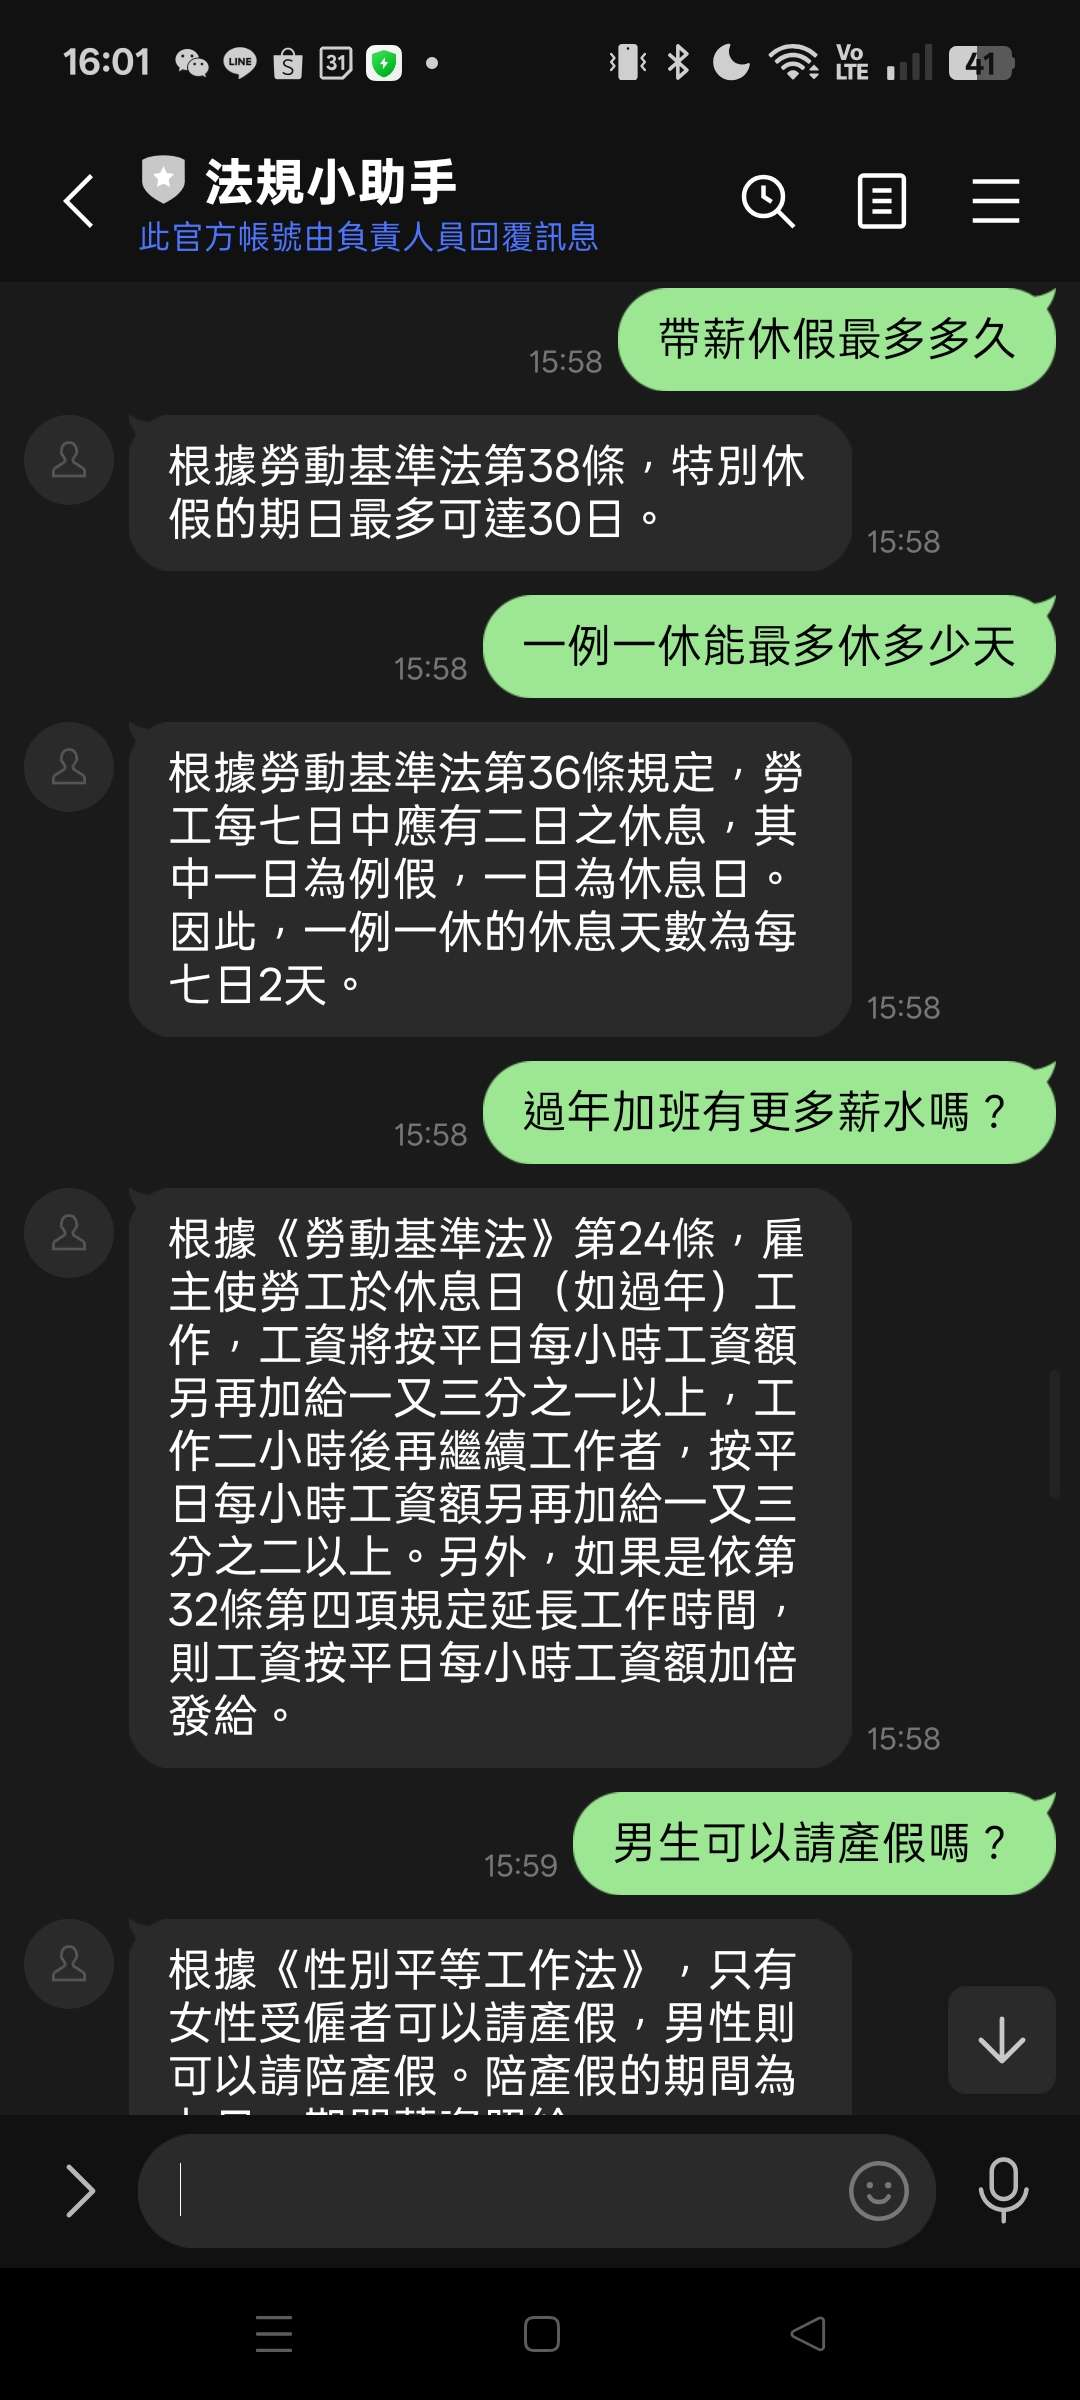
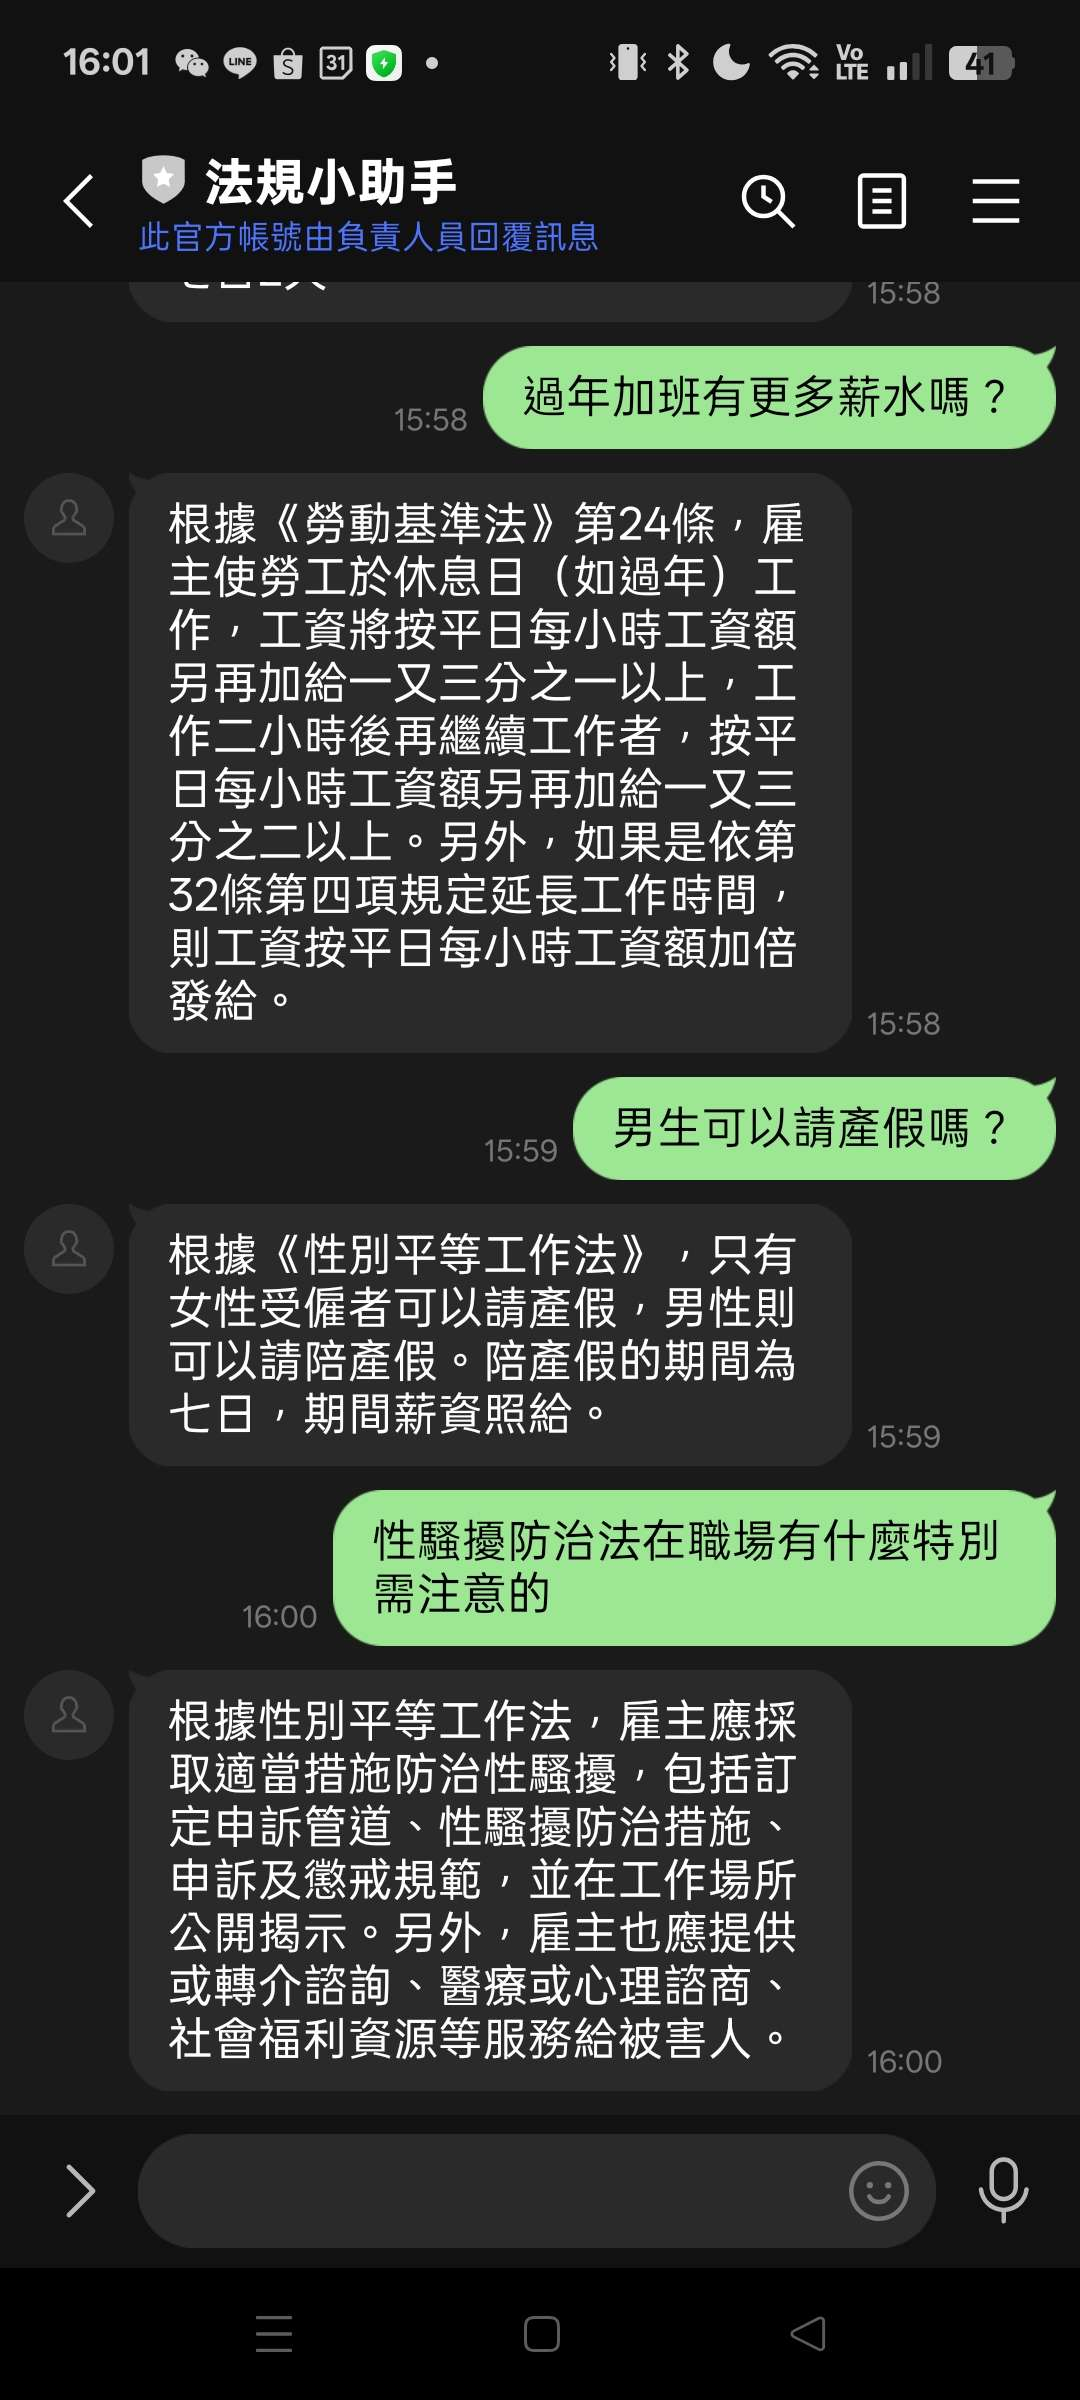